#CREATE SORT OF LINEAR DATA (ON WHICH GRADIENT DISCENT WILL BE APPLIED)

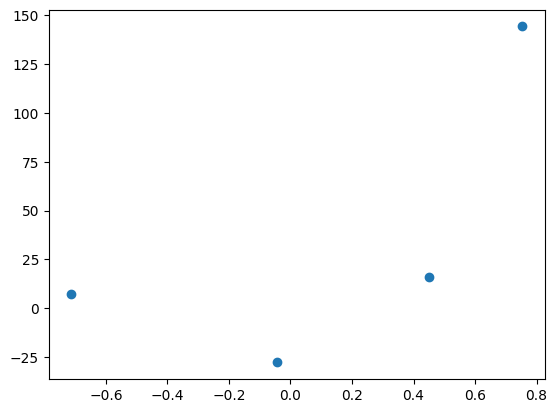

In [1]:
from sklearn.datasets import make_regression
import numpy as np

X,y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1,noise=80,random_state=13)

import matplotlib.pyplot as plt
plt.scatter(X,y)

# APPLY OLS

In [2]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X,y)

LinearRegression()

In [3]:
reg.coef_

array([78.35063668])

In [4]:
reg.intercept_

np.float64(26.15963284313262)

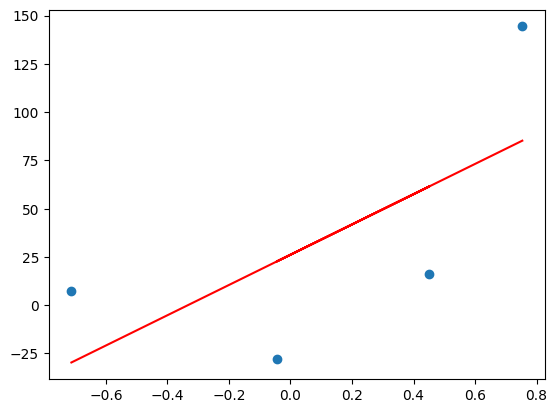

In [5]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red')

#Apply Gradient Descent (WHEN "m" IS KNOWN)

In [6]:
# Lets apply Gradient Descent assuming slope is constant m = 78.35
# and let's assume the starting value for intercept b = 0
y_pred = ((78.35 * X) + 0).reshape(4)
y_pred

array([-55.81580837,  35.39949674,  -3.48681619,  59.05759577])

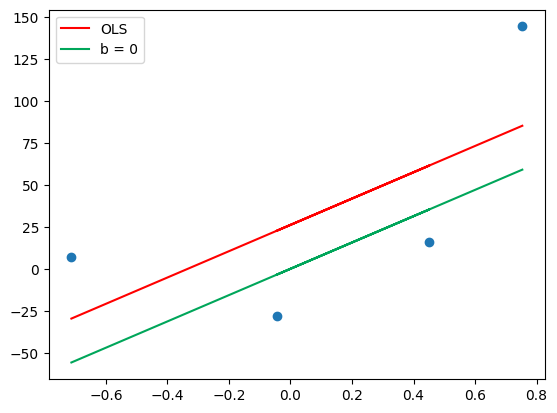

In [7]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='#00a65a',label='b = 0')
plt.legend()
plt.show()

#ITERATION NO 1

In [8]:
m = 78.35
b = 0

loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope
# calculation of slope at b=0

np.float64(-209.27763408209216)

In [9]:
# Lets take learning rate = 0.1
lr = 0.1

step_size = loss_slope*lr
step_size

np.float64(-20.927763408209216)

In [10]:
# Calculating the new intercept
b = b - step_size
b

np.float64(20.927763408209216)

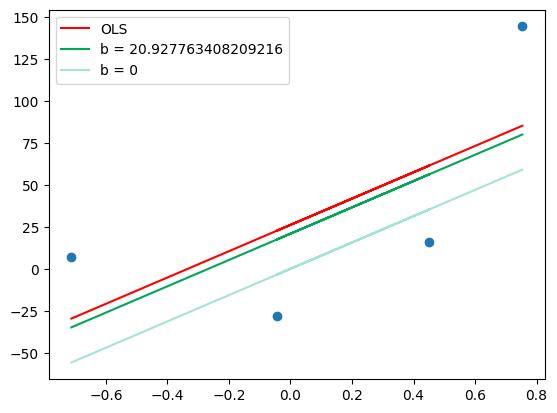

In [11]:
y_pred1 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred1,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

#ITERATION NO 2

In [12]:
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(-41.85552681641843)

In [13]:
step_size = loss_slope*lr
step_size

np.float64(-4.185552681641844)

In [14]:

b = b - step_size
b

np.float64(25.11331608985106)

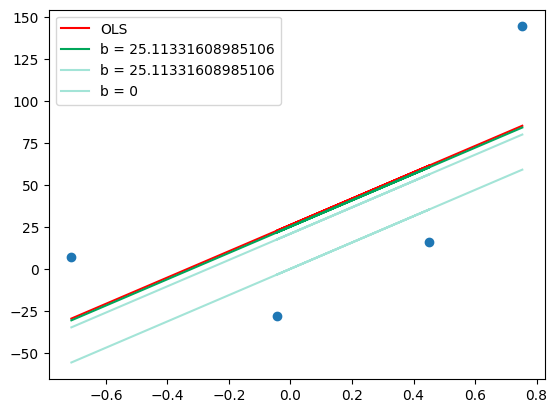

In [15]:
y_pred2 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred2,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

# COMPLETE CODE IN LOOP

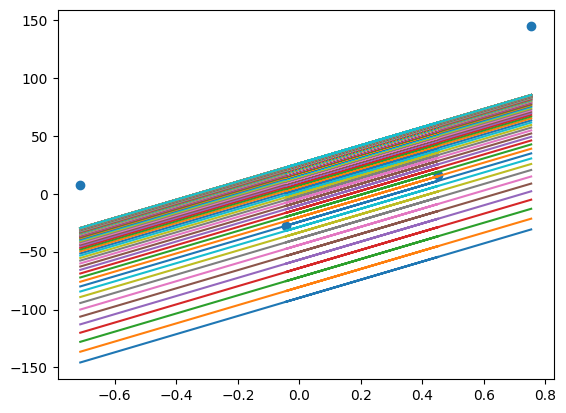

In [16]:
b = -100
m = 78.35
lr = 0.01

epochs = 100

for i in range(epochs):
  loss_slope = -2 * np.sum(y - m*X.ravel() - b)
  b = b - (lr * loss_slope)

  y_pred = m * X + b

  plt.plot(X,y_pred)

plt.scatter(X,y)

# BUILDING OUR OWN GRADIENT DISCENT(WHEN M IS KNOWN)

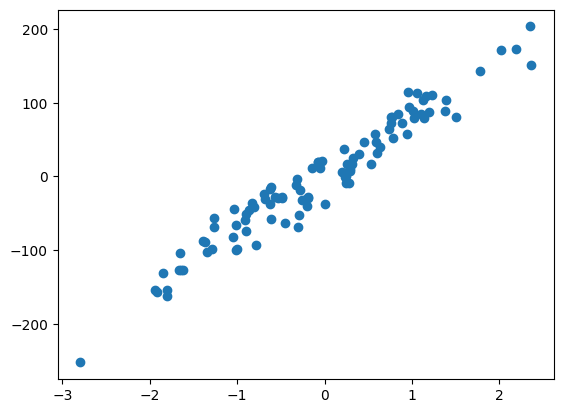

In [17]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20)
plt.scatter(X,y)

In [18]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X,y)
print(lr.coef_)
print(lr.intercept_)

[76.97999108]
2.3056121343454645


In [19]:
class GDRegressor:

    def __init__(self,learning_rate,epochs):
        self.m = 56.43
        self.b = 120
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X,y):
        # calcualte the b using GD
        for i in range(self.epochs):
            loss_slope = -2 * np.sum(y - self.m*X.ravel() - self.b)
            self.b = self.b - (self.lr * loss_slope)
            print(loss_slope,self.b)
        print(self.b)

In [20]:
gd = GDRegressor(0.001,100)
gd.fit(X,y)

23820.80690368876 96.17919309631124
19056.64552295101 77.12254757336022
15245.316418360804 61.87723115499942
12196.253134688644 49.680978020310775
9757.002507750913 39.92397551255986
7805.602006200732 32.118373506359134
6244.481604960587 25.873891901398547
4995.58528396847 20.878306617430077
3996.4682271747747 16.881838390255304
3197.1745817398205 13.684663808515483
2557.7396653918563 11.126924143123626
2046.1917323134846 9.08073241081014
1636.9533858507878 7.443779024959353
1309.5627086806303 6.134216316278723
1047.650166944504 5.086566149334219
838.1201335556033 4.248446015778616
670.4961068444827 3.5779499089341336
536.396885475586 3.0415530234585475
429.11750838046896 2.6124355150780785
343.2940067043749 2.2691415083737034
274.6352053635003 1.994506303010203
219.70816429080023 1.7747981387194027
175.76653143264022 1.5990316072867625
140.6132251461118 1.4584183821406507
112.4905801168895 1.3459278020237613
89.99246409351169 1.2559353379302496
71.99397127480924 1.1839413666554404
57.

#Apply Gradient Descent (WHEN both "m" and "b" are UNKNOWN)

- PICTURE DEPICTS THAT NOW THE LOSS FUNCION DEPENDS ON BOTH M AND B VALUE AND WE NEED TO CALCULATE THOSE M AND B VALUES FOR WHICH LOSS FUNCTION VALUE IS MINIMUM.

- WE CAN SAY THAT VISUALIZATION IS 3D PARABOLA

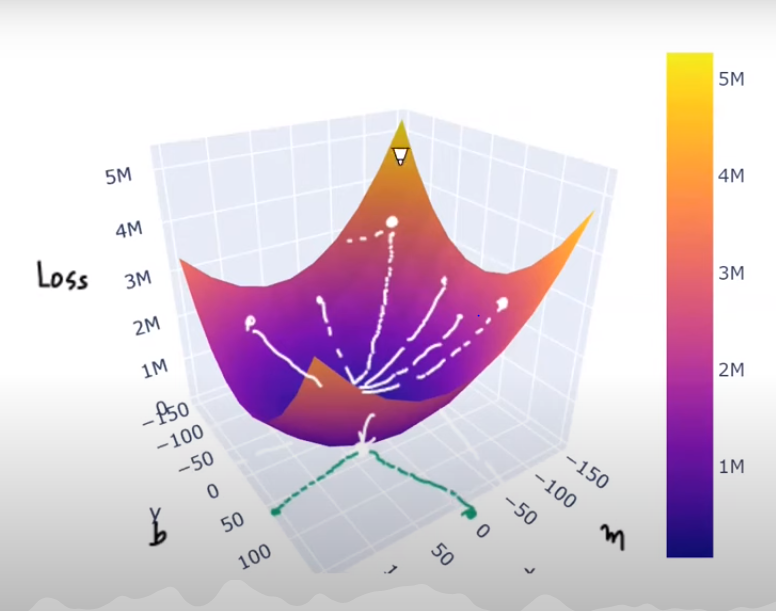

# create sort of linear data

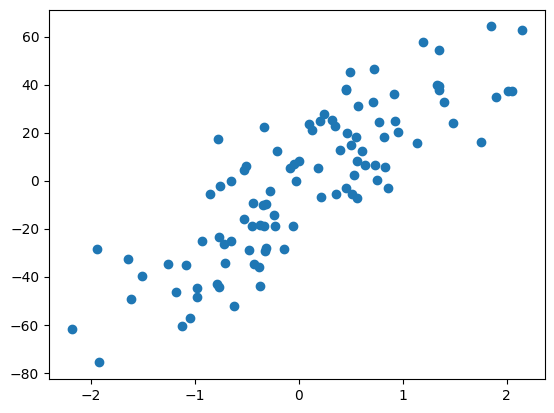

In [21]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)
plt.scatter(X,y)

# ols method applied

In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[28.12597332]
-2.2710144261783825


In [23]:
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6345158782661012

**Cross_val_score**

**It is a method which runs cross validation on a dataset to test whether the model can generalise over the whole dataset. The function returns a list of one score per split, and the average of these scores can be calculated to provide a single metric value for the dataset**

In [24]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(lr,X,y,scoring="r2",cv=10))

np.float64(0.6375011587464419)

# building our own gradient discent

In [25]:
class GDRegressor:

    def __init__(self,learning_rate,epochs):
        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X,y):
        # calcualte the b using GD
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b)*X.ravel())

            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)
        print(self.m,self.b)
    def predict(self,X):
      return self.m * X + self.b

In [26]:
gd = GDRegressor(0.001,50)
gd.fit(X_train,y_train)

28.159367347119066 -2.3004574196824854


In [27]:
y_pred = gd.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6343842836315579



---



---



---



---



---

